# Loss Given Default (LGD) Model

Predicts the fraction of exposure lost on a defaulted loan: `LGD = 1 - recovery_rate`,
where `recovery_rate = recoveries / EAD_at_default`. Feeds Expected Loss alongside the
PD model: `EL = PD x LGD x EAD` (EAD here is a separate, currently-active loan's own
outstanding balance at scoring time -- see project README for how the three components
combine without double-counting).

## Scope

LGD is only defined for loans that have actually defaulted -- this model is trained
on **Charged Off loans only**, a different (smaller) population than the PD model's
training set.

## Target definition

Standard LGD is loss as a fraction of **Exposure at Default (EAD)** -- the amount
still outstanding when the loan defaulted, not the loan's original size. Since
`out_prncp` is zeroed out once a loan is charged off, EAD at default is approximated
as `funded_amnt - total_rec_prncp` (original amount minus principal already repaid
via normal payments before charge-off). Dividing by the original `funded_amnt`
instead would overstate loss for any loan that had meaningfully paid down before
defaulting.

## Feature notes

Mostly reuses the PD model's origination feature set (loan/borrower characteristics
still affect how much gets recovered). Two differences worth noting:

- `prncp_repaid_ratio` (principal repaid via normal payments, as a fraction of the
  original loan) is included as a feature -- a distinct concept from `recoveries`
  (post-default collections activity), so this isn't circular with the target, and
  it's a well-documented real predictor of loss severity in the credit literature.
- `debt_settlement_flag` is included here, unlike in the PD model. There, it was
  excluded as leakage (entering settlement is a consequence of default, which would
  leak the very outcome being predicted). Here, default is already the entire
  population being modeled -- so whether a borrower settled is a genuine predictor
  of *how much* gets recovered, not a leak of *whether* default happened.
- `collection_recovery_fee`, `out_prncp`, `total_pymnt` remain excluded -- these
  overlap or are co-computed with the target itself.

## 1. Imports

In [1]:
!pip install xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 6)

import joblib
import os
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

RANDOM_STATE = 42

## 2. Load data — Charged Off loans only

In [4]:
lgd_load_cols = [
    'loan_status', 'funded_amnt', 'recoveries', 'total_rec_prncp',  # target construction
    'debt_settlement_flag',                                          # LGD-specific feature
    # Origination features (same rationale as the PD model)
    'annual_inc', 'verification_status', 'emp_length', 'home_ownership',
    'addr_state', 'dti', 'purpose', 'fico_range_low', 'fico_range_high',
    'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'delinq_2yrs', 'pub_rec_bankruptcies', 'earliest_cr_line',
    'loan_amnt', 'int_rate', 'term', 'installment', 'grade', 'sub_grade', 'issue_d',
]

lgd_df = pd.read_csv(
    "../Data/accepted_2007_to_2018Q4.csv",
    low_memory=False,
    usecols=lgd_load_cols
)

lgd_df = lgd_df[lgd_df['loan_status'] == 'Charged Off'].copy()
print(f"Charged Off loans: {lgd_df.shape}")

Charged Off loans: (268559, 29)


## 3. Target: recovery rate and LGD (relative to EAD at default)

Dropped 22 rows with non-positive EAD at default
count    268537.000000
mean          0.890438
std           0.133119
min           0.000000
25%           0.857650
50%           0.896916
75%           1.000000
max           1.000000
Name: lgd, dtype: float64


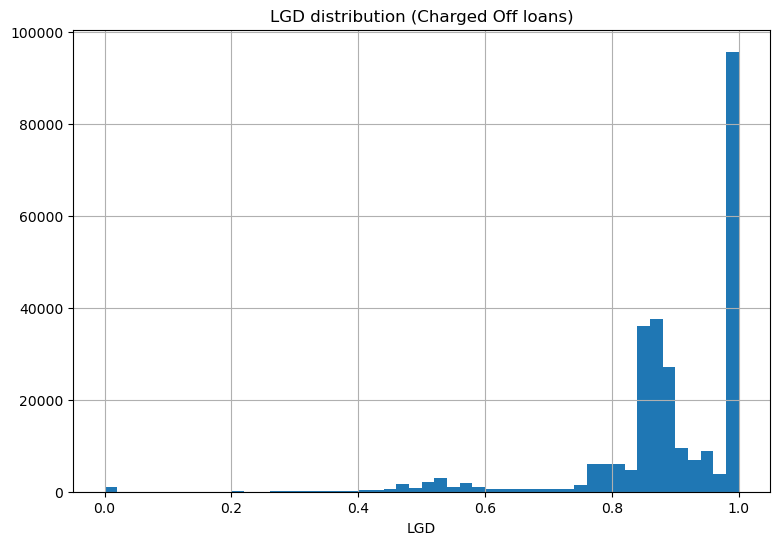

In [5]:
lgd_df = lgd_df[lgd_df['funded_amnt'] > 0]

# EAD at default -- what was actually still owed when the loan defaulted, not
# the original loan size. total_rec_prncp is principal already repaid via
# normal payments before charge-off; out_prncp isn't usable here since it's
# zeroed out once a loan is charged off.
lgd_df['ead_at_default'] = lgd_df['funded_amnt'] - lgd_df['total_rec_prncp']

# A handful of rows can have ead_at_default <= 0 (nearly fully repaid before
# charge-off) -- not meaningful for LGD estimation, so dropped.
before = len(lgd_df)
lgd_df = lgd_df[lgd_df['ead_at_default'] > 0]
print(f"Dropped {before - len(lgd_df)} rows with non-positive EAD at default")

lgd_df['recovery_rate'] = (lgd_df['recoveries'] / lgd_df['ead_at_default']).clip(0, 1)
lgd_df['lgd'] = 1 - lgd_df['recovery_rate']

lgd_df.drop(columns=['recoveries', 'funded_amnt', 'ead_at_default', 'loan_status'], inplace=True)

print(lgd_df['lgd'].describe())
lgd_df['lgd'].hist(bins=50)
plt.xlabel('LGD')
plt.title('LGD distribution (Charged Off loans)')
plt.show()

## 4. Feature engineering

In [7]:
lgd_df['debt_settlement_flag'] = (lgd_df['debt_settlement_flag'] == 'Y').astype(int)
lgd_df['home_ownership'] = lgd_df['home_ownership'].replace({'ANY': 'OTHER', 'NONE': 'OTHER'})

lgd_df['fico_score_origination'] = (lgd_df['fico_range_low'] + lgd_df['fico_range_high']) / 2
lgd_df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# Fraction of the ORIGINAL loan repaid via normal payments before charge-off --
# a well-documented predictor of loss severity (more paydown before default
# tends to mean lower eventual loss). Distinct from the EAD-based target above.
lgd_df['prncp_repaid_ratio'] = lgd_df['total_rec_prncp'] / (lgd_df['loan_amnt'] + 1)

In [8]:
lgd_df = pd.get_dummies(
    lgd_df, columns=['verification_status', 'home_ownership', 'purpose'], drop_first=True
)

emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
           '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
lgd_df['emp_length'] = lgd_df['emp_length'].map(emp_map)
lgd_df['term'] = lgd_df['term'].map({' 36 months': 0, ' 60 months': 1})

lgd_df = lgd_df[lgd_df['dti'] > 0]

addr_freq = lgd_df['addr_state'].value_counts(normalize=True)
lgd_df['addr_state_freq'] = lgd_df['addr_state'].map(addr_freq)
lgd_df.drop(columns=['addr_state'], inplace=True)

subgrade_order = [f"{g}{s}" for g in ['A','B','C','D','E','F','G'] for s in range(1, 6)]
subgrade_float_map = {sg: float(f"{i//5 + 1}.{i%5 + 1}") for i, sg in enumerate(subgrade_order)}
lgd_df['sub_grade'] = lgd_df['sub_grade'].map(subgrade_float_map)
lgd_df.drop(columns=['grade'], inplace=True)

lgd_df['revol_util'] = lgd_df['revol_util'].clip(upper=100)
lgd_df['annual_inc_log'] = np.log1p(lgd_df['annual_inc'])
lgd_df['revol_bal_log'] = np.log1p(lgd_df['revol_bal'])
lgd_df.drop(columns=['annual_inc', 'revol_bal'], inplace=True)

lgd_df['earliest_cr_line'] = pd.to_datetime(lgd_df['earliest_cr_line'], format='%b-%Y', errors='coerce')
lgd_df['issue_d'] = pd.to_datetime(lgd_df['issue_d'], format='%b-%Y', errors='coerce')
lgd_df['account_age_years'] = (lgd_df['issue_d'] - lgd_df['earliest_cr_line']).dt.days / 365.25
lgd_df.drop(columns=['earliest_cr_line', 'issue_d'], inplace=True)

In [9]:
for col in ['revol_util', 'emp_length']:
    lgd_df[f'{col}_missing'] = lgd_df[col].isna().astype(int)

lgd_df['revol_util'] = lgd_df['revol_util'].fillna(0)
lgd_df['emp_length'] = lgd_df['emp_length'].fillna(0)

lgd_df = lgd_df.dropna()
assert not np.isinf(lgd_df.select_dtypes(include=[np.number])).any().any(), "Inf values remain"
print(f"Final shape: {lgd_df.shape}")

Final shape: (268181, 43)


In [10]:
lgd_df[['prncp_repaid_ratio', 'lgd']].corr()

,prncp_repaid_ratio,lgd
prncp_repaid_ratio,1.000000,-0.039324
lgd,-0.039324,1.000000


## 5. Save processed data

In [11]:
lgd_df.to_parquet('../Data/lgd_df_processed.parquet')
print(f"Saved: {lgd_df.shape}")

Saved: (268181, 43)


In [12]:
lgd_df = pd.read_parquet('../Data/lgd_df_processed.parquet')
lgd_df.shape

(268181, 43)

## 6. Train / test split

In [13]:
# total_rec_prncp dropped here -- already used above to build ead_at_default
# (target construction) and prncp_repaid_ratio (feature); keeping the raw
# column too would be redundant.
X = lgd_df.drop(columns=['lgd', 'recovery_rate', 'total_rec_prncp'])
y = lgd_df['lgd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (214544, 40), Test: (53637, 40)


## 7. Evaluation helper

In [14]:
def evaluate_lgd_model(name, y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 0, 1)  # LGD is bounded [0,1] by definition
    return {
        'model': name,
        'mae': mean_absolute_error(y_true, y_pred_clipped),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred_clipped)),
        'r2': r2_score(y_true, y_pred_clipped),
    }

lgd_results = []
lgd_predictions = {}

## 8. Candidate models

In [15]:
# Linear Regression -- baseline. Can technically predict outside [0,1];
# clipped at evaluation/inference time.
linreg = LinearRegression()
linreg.fit(X_train, y_train)
pred_linreg = linreg.predict(X_test)

lgd_results.append(evaluate_lgd_model('Linear Regression', y_test, pred_linreg))
lgd_predictions['Linear Regression'] = pred_linreg

In [16]:
# Logit-link regression -- approximates Beta regression's bounded structure:
# transform the target to an unbounded scale, fit a linear model, invert back.
eps = 1e-4
y_train_logit = np.log((y_train.clip(eps, 1 - eps)) / (1 - y_train.clip(eps, 1 - eps)))

logit_model = Ridge(alpha=1.0)
logit_model.fit(X_train, y_train_logit)

pred_logit_raw = logit_model.predict(X_test)
pred_logit = 1 / (1 + np.exp(-pred_logit_raw))  # inverse logit -> back to [0,1]

lgd_results.append(evaluate_lgd_model('Logit-link Regression', y_test, pred_logit))
lgd_predictions['Logit-link Regression'] = pred_logit

In [17]:
xgb_lgd = xgb.XGBRegressor(
    max_depth=5, learning_rate=0.05, n_estimators=300,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
)
xgb_lgd.fit(X_train, y_train)
pred_xgb = xgb_lgd.predict(X_test)

lgd_results.append(evaluate_lgd_model('XGBoost', y_test, pred_xgb))
lgd_predictions['XGBoost'] = pred_xgb

## 9. Comparison

In [18]:
lgd_comparison_df = pd.DataFrame(lgd_results).sort_values('mae')
lgd_comparison_df

,model,mae,rmse,r2
2,XGBoost,0.082350,0.115709,0.235193
0,Linear Regression,0.085273,0.119066,0.190176
1,Logit-link Regression,0.099740,0.149735,-0.280746


## 10. Calibration-style check

Regression R-squared alone doesn't show whether predictions are systematically
biased at particular LGD levels. Bucketing by predicted decile and comparing to
actual mean LGD is the regression equivalent of a classification calibration curve.

Best model: XGBoost
                predicted_mean  actual_mean  count
decile                                            
(0.545, 0.786]        0.723525     0.714752   5364
(0.786, 0.892]        0.868217     0.875111   5364
(0.892, 0.899]        0.896028     0.892331   5363
(0.899, 0.904]        0.901864     0.899440   5364
(0.904, 0.908]        0.906232     0.904137   5364
(0.908, 0.912]        0.910221     0.908808   5363
(0.912, 0.917]        0.914380     0.917070   5364
(0.917, 0.922]        0.919226     0.921257   5363
(0.922, 0.93]         0.925752     0.930561   5364
(0.93, 1.0]           0.940200     0.946672   5364


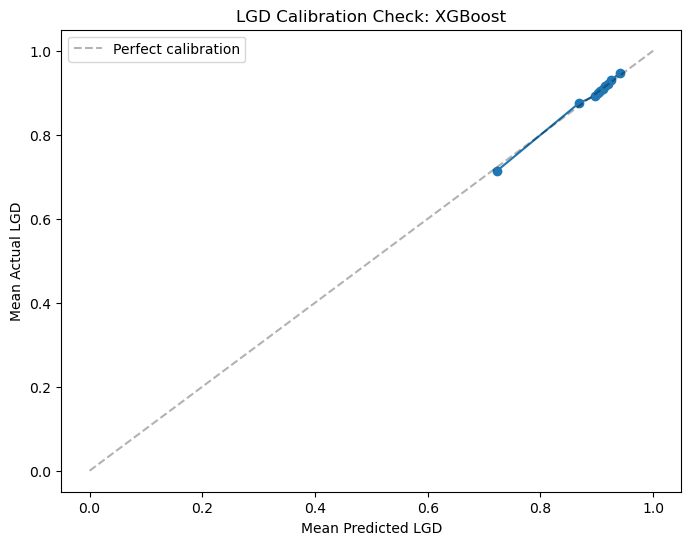

In [19]:
best_model_name = lgd_comparison_df.iloc[0]['model']
best_pred = lgd_predictions[best_model_name]

check_df = pd.DataFrame({'predicted': np.clip(best_pred, 0, 1), 'actual': y_test.values})
check_df['decile'] = pd.qcut(check_df['predicted'], 10, duplicates='drop')

decile_summary = check_df.groupby('decile', observed=True).agg(
    predicted_mean=('predicted', 'mean'),
    actual_mean=('actual', 'mean'),
    count=('actual', 'size')
)
print(f"Best model: {best_model_name}")
print(decile_summary)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(decile_summary['predicted_mean'], decile_summary['actual_mean'], marker='o')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
ax.set_xlabel('Mean Predicted LGD')
ax.set_ylabel('Mean Actual LGD')
ax.set_title(f'LGD Calibration Check: {best_model_name}')
ax.legend()
plt.show()

## 11. Save model artifact

In [20]:
final_lgd_model = xgb_lgd if best_model_name == 'XGBoost' else linreg
joblib.dump(final_lgd_model, '../Models/lgd_model.joblib')
joblib.dump(list(X.columns), '../Models/lgd_model_feature_names.joblib')

print(f"Saved: {best_model_name}")
print(f"Test performance: {evaluate_lgd_model(best_model_name, y_test, best_pred)}")

Saved: XGBoost
Test performance: {'model': 'XGBoost', 'mae': 0.08235034619073656, 'rmse': np.float64(0.11570904834529289), 'r2': 0.2351930157574993}


## 12. Inference example

In [25]:
lgd_model = joblib.load('../Models/lgd_model.joblib')
lgd_feature_names = joblib.load('../Models/lgd_model_feature_names.joblib')

def predict_lgd(df: pd.DataFrame) -> np.ndarray:
    missing = [f for f in lgd_feature_names if f not in df.columns]
    for f in missing:
        df[f] = 0
    return np.clip(lgd_model.predict(df[lgd_feature_names]), 0, 1)

# Example: reuse a row from the test set
example = X_test.iloc[[0]]
print(f"Predicted LGD: {predict_lgd(example)[0]:.4f}")
print(f"Actual LGD:    {y_test.iloc[0]:.4f}")

Predicted LGD: 0.9076
Actual LGD:    0.9005


In [2]:
import pandas as pd

status_counts = pd.read_csv(
    "../Data/accepted_2007_to_2018Q4.csv",
    usecols=['loan_status'],
    low_memory=False
)['loan_status'].value_counts()

print(status_counts)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64
